# Preparation and Set up

## Import Necessary Resources

### Import Libraries

In [2]:
# Import necessary libraries
import sqlite3
from sqlite3 import Error
import kagglehub
import csv
import os

import pandas as pd
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt

import ipywidgets as widgets
from IPython.display import display, Image, clear_output
from PIL import Image as PILImage
import io

### Import the Dataset

In [6]:
# Download the datasets
path = kagglehub.dataset_download("alessandrasala79/ai-vs-human-generated-dataset")
# https://ieee-dataport.org/documents/deepguarddb-real-and-text-image-synthetic-images-dataset#files

training_labels = []
train_path = os.path.join(path, 'train.csv')

with open(train_path, 'r') as file:
    reader = csv.reader(file)
    next(reader)  # Skip the header row
    for row in reader:
        image_label = row[2]
        training_labels.append(image_label)

## Prepare the Data

### Data Augmentation

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

### Create Data Pipelines

In [9]:
# Set the GPU memory growth to avoid OOM errors
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
    
# Read the image data
def load_image(image_file, label=None):
    print(image_file)
    image_file = tf.squeeze(image_file)
    image = tf.io.read_file(image_file)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.rgb_to_grayscale(image)
    image = tf.image.resize(image, [250, 250])
    image = tf.cast(image, tf.float32) / 255.0
    
    return image, label

# Function to set dataset properties
def setup_dataset(dataset):
    dataset = dataset.map(load_image)
    dataset = dataset.shuffle(80000)
    dataset = dataset.batch(64).prefetch(tf.data.AUTOTUNE)
    return dataset

# Plot a batch of images
def plot_images(images, labels):
    plt.figure(figsize=(10, 10))
    # Plot 16 images in a 4x4 grid
    for i in range(16):
        # Determine the label for the image
        label = labels[i]
        if labels[i] == 1:
            label = 'AI'
        else:
            label = 'Human'
            
        # Create a subplot for each image
        ax = plt.subplot(4, 4, i + 1)
        # Load and display the image and label
        plt.imshow(images[i])
        plt.title(label)
        plt.axis('off')
    # Show the plot
    plt.show()

# Setup train dataset
train_df = pd.read_csv(train_path)
train_paths = [os.path.join(path, file) for file in train_df['file_name'].values]
train_labels = train_df['label'].values
train_images = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_images = setup_dataset(train_images)

data_iterator = train_images.as_numpy_iterator()
imgs, lbls = data_iterator.next()

Tensor("args_0:0", shape=(), dtype=string)


### Define Data Partitions

In [63]:
train_size = int(len(train_images) * 0.7)
val_size = int(len(train_images) * 0.2)
test_size = len(train_images) - train_size - val_size

train_data = train_images.take(train_size)
val_data = train_images.skip(train_size).take(val_size)
test_data = train_images.skip(train_size + val_size).take(test_size)



## Create the Model

### Define Model

In [62]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(250,250,1)),
    data_augmentation,
    
    tf.keras.layers.Conv2D(16, (3,3), 1, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Conv2D(64, (3,3), 1, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Conv2D(16, (3,3), 1, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

### Compile Model

In [63]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

### Model Summary

In [3]:
model.summary()

NameError: name 'model' is not defined

### Train the Model

In [ ]:
logdir = 'logs'
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)
history = model.fit(train_data, epochs=75, validation_data=val_data, callbacks=[tensorboard_callback])

Epoch 1/20
1749/1749 ━━━━━━━━━━━━━━━━━━━━ 2744s 1s/step - accuracy: 0.7900 - loss: 0.5773 - val_accuracy: 0.8310 - val_loss: 0.3796
Epoch 2/20
1749/1749 ━━━━━━━━━━━━━━━━━━━━ 3588s 2s/step - accuracy: 0.8556 - loss: 0.3447 - val_accuracy: 0.7057 - val_loss: 0.9089
Epoch 3/20
1749/1749 ━━━━━━━━━━━━━━━━━━━━ 3485s 2s/step - accuracy: 0.9130 - loss: 0.2222 - val_accuracy: 0.5450 - val_loss: 2.5382
Epoch 4/20
1749/1749 ━━━━━━━━━━━━━━━━━━━━ 2787s 1s/step - accuracy: 0.9356 - loss: 0.1679 - val_accuracy: 0.7573 - val_loss: 0.5915
Epoch 5/20
1749/1749 ━━━━━━━━━━━━━━━━━━━━ 6814s 4s/step - accuracy: 0.9554 - loss: 0.1199 - val_accuracy: 0.8094 - val_loss: 0.4352
Epoch 6/20
1749/1749 ━━━━━━━━━━━━━━━━━━━━ 2775s 1s/step - accuracy: 0.9631 - loss: 0.1021 - val_accuracy: 0.7965 - val_loss: 0.4958
Epoch 7/20
1749/1749 ━━━━━━━━━━━━━━━━━━━━ 57197s 32s/step - accuracy: 0.9657 - loss: 0.0925 - val_accuracy: 0.9508 - val_loss: 0.1468
Epoch 8/20
1749/1749 ━━━━━━━━━━━━━━━━━━━━ 2623s 1s/step - accuracy: 0.9660

### Save the Model

In [ ]:
model.save('AImageModelv5.keras')

## Load the Model

In [12]:
model = tf.keras.models.load_model('AImageModelv4.keras')

# Predictions

In [13]:
# Function to handle the upload event
def on_upload_change(change):
    with out:
        clear_output(wait=True)  # Clear previous output
        label.value = 'Uploaded Successfully'
        # Get the image and predict 
        uploaded_files = change['new']
        if uploaded_files:
            uploaded_file = uploaded_files[0]  # Get first file
            image_data = uploaded_file['content']  # Image as bytes
            
            # Convert image bytes to PIL grayscale (1 channel)
            pil_image = PILImage.open(io.BytesIO(image_data)).convert("L")

            
            # Resize the image to model's expected input shape
            pil_image = pil_image.resize((250, 250))  
            
            # Convert image to numpy array
            img_array = np.array(pil_image)
            
            # Normalize pixel values (assuming model expects values in range [0,1])
            img_array = img_array / 255.0  
            
            # Add batch dimension (assuming model expects shape: (batch_size, height, width, channels))
            img_array = np.expand_dims(img_array, axis=0)  

            # Make prediction
            prediction = model.predict(img_array)
            
            # Display the image
            display(pil_image)
            
            # Display the prediction result
            label.value = f"Value: {prediction[0][0]} Prediction: {'AI-Generated' if prediction[0][0] > 0.5 else 'Human-Created'}"
    
# Create an image upload widget
upload_btn = widgets.FileUpload(
    accept='.jpg,.jpeg,.png',  # Acceptable file formats
    multiple=False  # Allow only one file at a time
)

# Create the Output widget to display the image
out = widgets.Output()
label = widgets.Label(value="")

# Attach event listener
upload_btn.observe(on_upload_change, names='value')

# Display the UI
display(upload_btn, label, out)


FileUpload(value=(), accept='.jpg,.jpeg,.png', description='Upload')

Label(value='')

Output()

# Reporting and Visualizations

## Data Visualizations

### Example Training Image Data

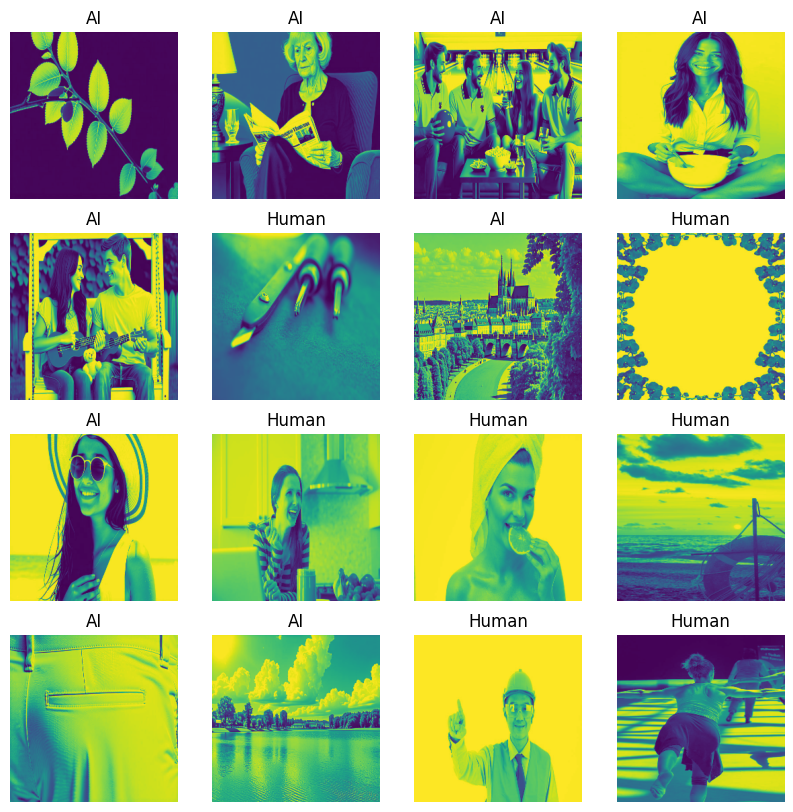

In [27]:
# Create a function to plot images
plot_images(imgs, lbls)

### Data Makeup

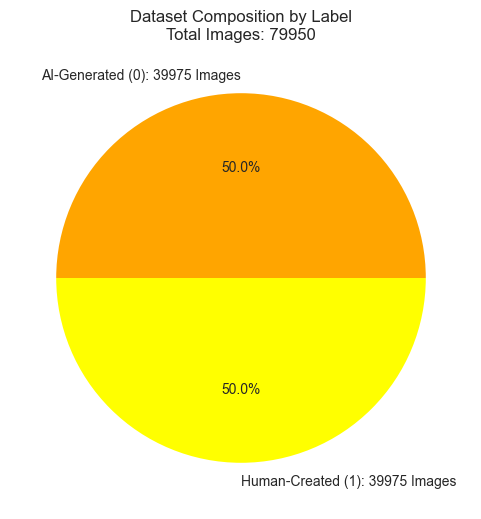

In [60]:
# Count occurrences of each label
unique_labels, counts = np.unique(train_labels, return_counts=True)
total = sum(counts)

# Labels with counts
labels = [f'AI-Generated (0): {counts[0]} Images', f'Human-Created (1): {counts[1]} Images']

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=['orange', 'yellow'])
plt.title(f'Dataset Composition by Label\nTotal Images: {total}')
plt.show()

## Model Metrics

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 

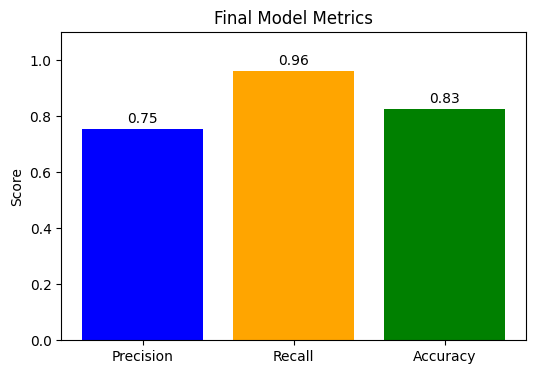

In [34]:
# Make sure predictions are for the current model
precision = tf.keras.metrics.Precision()
recall = tf.keras.metrics.Recall()
accuracy = tf.keras.metrics.BinaryAccuracy()


for batch in test_data.as_numpy_iterator():
    x, y = batch
    prediction = model.predict(x)
    precision.update_state(y, prediction)
    recall.update_state(y, prediction)
    accuracy.update_state(y, prediction)

# Display the final metrics
metrics = [precision.result().numpy(), recall.result().numpy(), accuracy.result().numpy()]
metric_names = ['Precision', 'Recall', 'Accuracy']

plt.figure(figsize=(6, 4))
plt.bar(metric_names, metrics, color=['blue', 'orange', 'green'])
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Final Model Metrics')

for i, v in enumerate(metrics):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()

## Training Performance Over Time (Will NOT Work With a Loaded Model)

### Loss While Training

In [18]:
fig = plt.figure()
plt.plot(history.history['loss'], color='orange', label='Training Loss')
plt.plot(history.history['val_loss'], color='red', label='Validation Loss')
plt.margins(0)
plt.xticks(np.arange(0, 20, 5))
plt.yticks(np.arange(0,0.4,0.02))
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("Loss While Training", fontsize=18)
plt.legend(loc='upper left')
plt.show()

NameError: name 'history' is not defined

<Figure size 640x480 with 0 Axes>

### Accuracy While Training

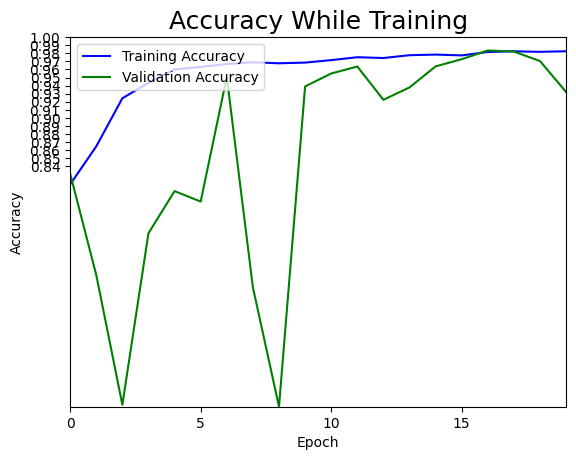

In [38]:
fig = plt.figure()
plt.plot(history.history['accuracy'], color='blue', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], color='green', label='Validation Accuracy')
plt.margins(0)
plt.xticks(np.arange(0, 20, 5))
plt.yticks(np.arange(0.84, 1, 0.01))
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("Accuracy While Training", fontsize=18)
plt.legend(loc='upper left')
plt.show()